In [1]:
from SMUControlAgilent2900 import AgilentB2902A, discover_instruments
import numpy as np
import matplotlib.pyplot as plt

In [2]:
insts = discover_instruments()
display(insts)

('USB0::0x0957::0x8C18::MY51140533::INSTR',)

In [3]:
# Device should beep when connected.
device = AgilentB2902A(insts[0])

In [4]:
device.sounds = False
device.set_source(device.mode.VOLT)
device.set_sense(device.mode.CURR, 1e-3)

In [5]:
voltages = np.linspace(-1, 1, 21)
voltages

array([-1. , -0.9, -0.8, -0.7, -0.6, -0.5, -0.4, -0.3, -0.2, -0.1,  0. ,
        0.1,  0.2,  0.3,  0.4,  0.5,  0.6,  0.7,  0.8,  0.9,  1. ])

In [ ]:
# Test a measurement and show the result.
device.sounds = True # Turn on or off
data = device.run_timed_IV_measurement(
    voltages=voltages.tolist(),
    meas_interval=0.1,
    settle_time=0.05,
)

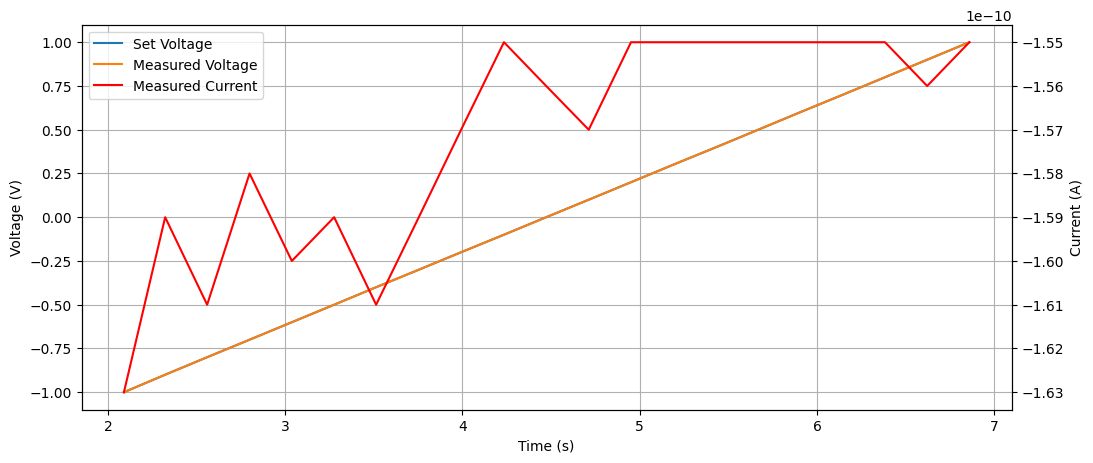

In [11]:
time, set_volt, meas_curr, meas_volt = data.T
fig, ax = plt.subplots(1, 1, figsize=(12, 5))
twinx = ax.twinx()
l1 = ax.plot(time, set_volt, label="Set Voltage")
l2 = ax.plot(time, meas_volt, label="Measured Voltage")
l3 = twinx.plot(time, meas_curr, label="Measured Current", color="red")
ax.set_xlabel("Time (s)")
ax.set_ylabel("Voltage (V)")
twinx.set_ylabel("Current (A)")

ax.legend(handles=l1 + l2 + l3)

ax.grid(True)

In [8]:
device.close()